In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay ,recall_score, precision_score ,accuracy_score ,roc_auc_score, RocCurveDisplay

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [51]:

df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\project1\Data\synthetic_heart_disease_dataset.csv", keep_default_na=False)
df.head(3)

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,None,Sedentary,Healthy,Medium,0,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,1,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,None,Moderate,Average,Medium,0,0,0,1,0,116,102,78,148,208,0


#### Target and features

In [60]:
heart_data = df.drop(columns= 'Heart_Disease') 

X = pd.get_dummies(heart_data, drop_first= True)  # features , one hot encoding (converts categorical columns in diabetes into numerical columns)
y = df['Heart_Disease'] # target

print(f"Number of features after encoding: {X.shape[1]}")

print("\nTarget counts:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))


Number of features after encoding: 26

Target counts:
Heart_Disease
0    26827
1    23173
Name: count, dtype: int64

Target percentages:
Heart_Disease
0    53.65
1    46.35
Name: proportion, dtype: float64


#### Train / test split

In [61]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape:  {X_test.shape}")

print("\nTraining target percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training data shape: (40000, 26)
Testing data shape:  (10000, 26)

Training target percentages:
Heart_Disease
0    53.65
1    46.34
Name: proportion, dtype: float64

Testing target percentages:
Heart_Disease
0    53.65
1    46.35
Name: proportion, dtype: float64


### Models and cross-validation

I used F1-score for the grid searches so that precision and recall are both considered.

`cv=5` uses 5 folds. For classification, GridSearchCV uses stratified folds by default.

#### Logistic Regression:

In [53]:
# Using pipeline since logistic regression requires scaling
pipe_LR = Pipeline([('scaler',StandardScaler()) , ('LR', LogisticRegression(random_state=42))])

param_grid_LR = {
    'LR__C': [0.1, 1.0, 10.0],
    'LR__penalty': ['l1', 'l2']  # tries ridge vs lasso for regularization
}

grid_lr = GridSearchCV(pipe_LR, param_grid_LR, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'LR__C': [0.01, 0.1, ...], 'LR__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information prin

#### RandomForest:

In [54]:


RF = RandomForestClassifier(random_state=42)

param_grid_RF = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10], 
    'min_samples_split': [2, 5]
}



grid_rf = GridSearchCV(RF, param_grid_RF, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

#### Decision Tree:

At first i tried SVM, but then I replaced SVM with Decision Tree because SVM was taking too long on this dataset.

In [64]:
DT = DecisionTreeClassifier(random_state=42)

param_grid_DT = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(DT, param_grid_DT, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information

#### Cross-validation results

In [ ]:
print("Logistic Regression's Best parameters:")
print(grid_lr.best_params_)

print("\nRandom Forest's Best parameters:")
print(grid_rf.best_params_)

print("\nDecision Tree's Best parameters:")
print(grid_dt.best_params_)

print(f"\nLogistic Regression Best CV F1-Score: {grid_lr.best_score_:.4f}")
print(f"Random Forest Best CV F1-Score:       {grid_rf.best_score_:.4f}")
print(f"Decision Tree Best CV F1-Score:       {grid_dt.best_score_:.4f}")

#### Final test set evaluation

The test set was not used during the grid searches. It is used here for the final evaluation.

In [65]:
pred_LR = grid_lr.predict(X_test)
pred_RF = grid_rf.predict(X_test)
pred_DT = grid_dt.predict(X_test)

print("--- Logistic Regression ---")
print(classification_report(y_test, pred_LR))

print("--- Random Forest ---")
print(classification_report(y_test, pred_RF))

print("--- Decision Tree ---")
print(classification_report(y_test, pred_DT))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5365
           1       0.92      0.92      0.92      4635

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5365
           1       1.00      1.00      1.00      4635

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

--- Decision Tree ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5365
           1       1.00      1.00      1.00      4635

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
we

#### Metrics comparison:

In [67]:
# probabilities are used for ROC-AUC
prob_LR = grid_lr.predict_proba(X_test)[:, 1]
prob_RF = grid_rf.predict_proba(X_test)[:, 1]
prob_DT = grid_dt.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    
    'CV F1': [grid_lr.best_score_, grid_rf.best_score_, grid_dt.best_score_],
    
    'Accuracy': [accuracy_score(y_test, pred_LR), accuracy_score(y_test, pred_RF), accuracy_score(y_test, pred_DT) ],
    
    'Precision': [precision_score(y_test, pred_LR), precision_score(y_test, pred_RF), precision_score(y_test, pred_DT)],
    
    'Recall': [ recall_score(y_test, pred_LR), recall_score(y_test, pred_RF), recall_score(y_test, pred_DT)],

    'F1': [f1_score(y_test, pred_LR), f1_score(y_test, pred_RF), f1_score(y_test, pred_DT)],
    
    'ROC-AUC': [roc_auc_score(y_test, prob_LR), roc_auc_score(y_test, prob_RF), roc_auc_score(y_test, prob_DT)]
})

results.round(4)

,Model,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.919,0.9237,0.9178,0.9176,0.9177,0.9822
1,Random Forest,1.000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Decision Tree,1.000,1.0000,1.0000,1.0000,1.0000,1.0000


#### CONFUSION MATRICES:

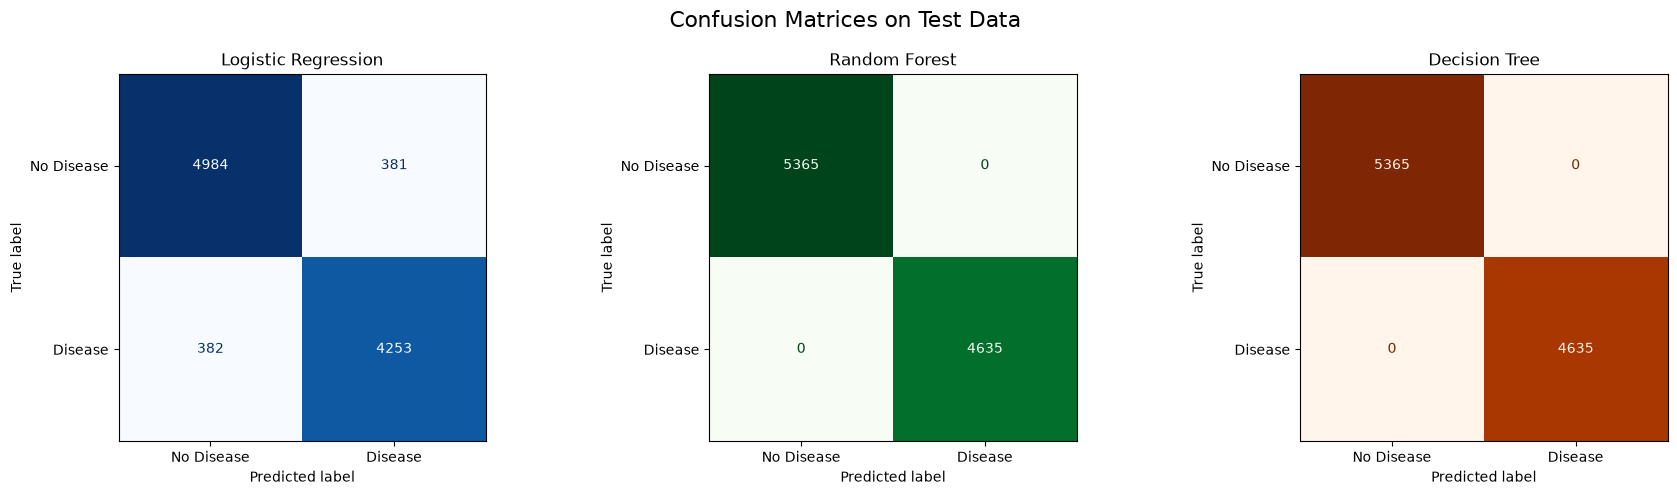

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_LR), display_labels=['No Disease', 'Disease']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_RF), display_labels=['No Disease', 'Disease']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest')

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_DT), display_labels=['No Disease', 'Disease']).plot(ax=axes[2], cmap='Oranges', colorbar=False) 
axes[2].set_title('Decision Tree')

plt.suptitle("Confusion Matrices on Test Data", fontsize=16)
plt.tight_layout()
plt.show()

### False positives and false negatives

- False Positive (FP): the model predicts heart disease, but the actual value is 0.
- False Negative (FN): the model predicts no heart disease, but the actual value is 1.

False negatives are important to look at because these are positive heart disease cases that the model missed.

#### ROC curves

ROC-AUC measures how well the model separates the two classes acrross different regions, A value closer to 1 is better.

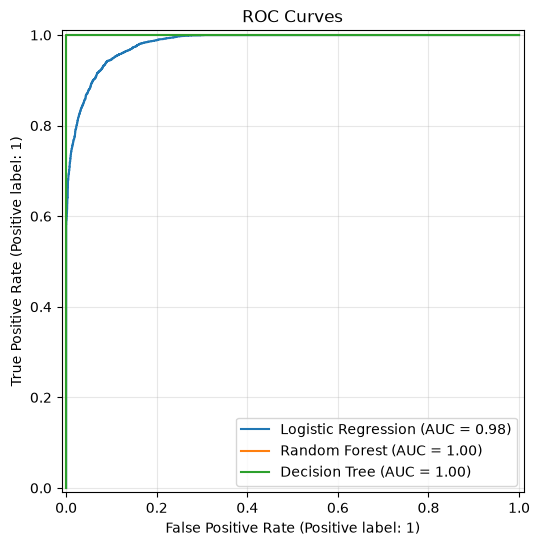

In [71]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, prob_LR, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, prob_RF, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, prob_DT, name='Decision Tree', ax=ax)

plt.title('ROC Curves')
plt.grid(alpha=0.3)
plt.show()

#### Random Forest feature importance

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_41204\149396506.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = rf_importances, x ='Importance', y = 'Feature', palette= 'viridis')


<Axes: xlabel='Importance', ylabel='Feature'>

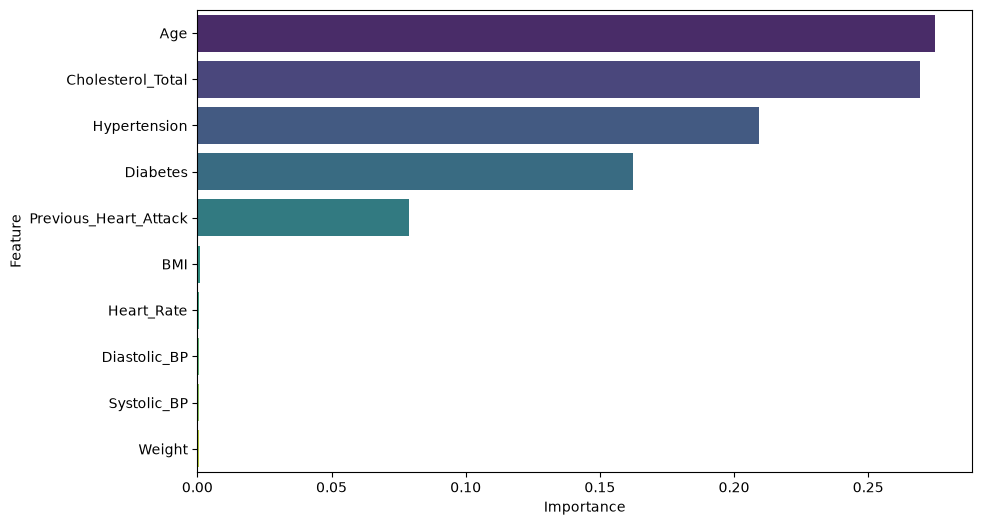

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

best_rf = grid_rf.best_estimator_

rf_importances = pd.DataFrame({'Feature': X_train.columns , 'Importance' : best_rf.feature_importances_}).sort_values(by= 'Importance', ascending= False).head(10)

sns.barplot(data = rf_importances, x ='Importance', y = 'Feature', palette= 'viridis')



## Final comparison

The final model should not be chosen using accuracy only. F1-score, recall, ROC-AUC and the confusion matrix should also be checked.

The cross-validation result should also be close to the test result. If one model performs much better on the training/CV data than on the test data, it may be overfitting.

In [72]:
results.sort_values(by='F1', ascending=False).round(4)

,Model,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,1.000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Decision Tree,1.000,1.0000,1.0000,1.0000,1.0000,1.0000
0,Logistic Regression,0.919,0.9237,0.9178,0.9176,0.9177,0.9822
